# Data Science – Machine Learning Assessment¶

## Submitted by Devang Lad

Email: devangladb@gmail.com

# <font color='magenta'>Part I - Exploratory Data Analysis</font> 

Changes or fixes done by giving explicit thought to how this data analysis will help build a working model.

## Step 1: Import libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('classic')
#pd.set_option('max-columns',200)

from scipy.stats import chi2_contingency   # Chi-square test

# Libraries for fitting
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.metrics import roc_curve

import shap        # for visualisation of governing paramters

In [2]:
# Training Data
TD = pd.read_csv('../tesco-dataset/df_train.csv')

In [3]:
TD.head()

,id,app_or_website,customer_collects,customer_segmentation,is_a_repeat_order,lead_time,n_customer_notes,n_items_above_quantity_10,n_listed_addresses,n_listed_payment_methods,n_previous_cancelled_orders,n_previous_completed_orders,n_small_items,payment_type,slot_date,store_number,total_price,status
0,TID32798,website,0.0,group_1,0.0,12.421322,0.0,2.0,1.0,1.0,0.0,0.0,0.0,debit,2018-09-25 00:00:00,id_58,69.243353,Not_Canceled
1,TID29290,app,NaN,group_1,0.0,39.849103,0.0,0.0,1.0,2.0,0.0,0.0,2.0,credit,2018-07-22 00:00:00,id_29,59.937542,Not_Canceled
2,TID16941,website,0.0,group_1,0.0,1.608750,1.0,0.0,1.0,2.0,0.0,0.0,1.0,debit,2019-07-12 00:00:00,id_4,84.391362,Not_Canceled
3,TID02831,app,0.0,group_1,0.0,116.432876,0.0,2.0,1.0,1.0,0.0,0.0,1.0,debit,2019-02-05 00:00:00,id_19,46.689214,Not_Canceled
4,TID22422,app,NaN,group_1,0.0,71.181542,1.0,0.0,1.0,2.0,0.0,0.0,3.0,credit,2019-04-17 00:00:00,id_8,72.215528,Not_Canceled


In [4]:
TD.info()             # checking data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           4000 non-null   object 
 1   app_or_website               4000 non-null   object 
 2   customer_collects            3819 non-null   float64
 3   customer_segmentation        3982 non-null   object 
 4   is_a_repeat_order            3608 non-null   float64
 5   lead_time                    4000 non-null   float64
 6   n_customer_notes             4000 non-null   float64
 7   n_items_above_quantity_10    4000 non-null   float64
 8   n_listed_addresses           4000 non-null   float64
 9   n_listed_payment_methods     3608 non-null   float64
 10  n_previous_cancelled_orders  4000 non-null   float64
 11  n_previous_completed_orders  4000 non-null   float64
 12  n_small_items                4000 non-null   float64
 13  payment_type      

## Step 2: Missing Value analysis

**<font color='blue'>   Total column:18; rows: 4000               </font>**

**<font color='blue'> Expected  Key columns of interest:  4-is_a_repeat_order; 8-n_listed_addresses; 10-n_previous_cancelled_orders; 15-store_number; 16-total_price    </font>** (assumption)

In [5]:
TD.isnull().sum()                # Checking for NaN columns

id                               0
app_or_website                   0
customer_collects              181
customer_segmentation           18
is_a_repeat_order              392
lead_time                        0
n_customer_notes                 0
n_items_above_quantity_10        0
n_listed_addresses               0
n_listed_payment_methods       392
n_previous_cancelled_orders      0
n_previous_completed_orders      0
n_small_items                    0
payment_type                     0
slot_date                        0
store_number                     0
total_price                      0
status                           0
dtype: int64

In [6]:
TD.duplicated().sum()    # check for double counting -

0

NO DUPLICATE ROWS IN DATA

In [7]:
for col in TD.columns:
    if TD[col].nunique() > 20:
        print(f"Unique values in {col}: More than 20 unique values")
    else:
        print(f"Unique values in {col}: {TD[col].unique()}")

Unique values in id: More than 20 unique values
Unique values in app_or_website: ['website' 'app' 'telephone' 'whoosh']
Unique values in customer_collects: [ 0. nan  1.]
Unique values in customer_segmentation: ['group_1' 'group_4' 'group_5' 'group_6' nan 'group_2']
Unique values in is_a_repeat_order: [ 0. nan  1.]
Unique values in lead_time: More than 20 unique values
Unique values in n_customer_notes: [0. 1. 2. 3. 4. 5.]
Unique values in n_items_above_quantity_10: [2. 0. 1. 3. 4. 6.]
Unique values in n_listed_addresses: [1. 3. 2. 4.]
Unique values in n_listed_payment_methods: [ 1.  2. nan  3.  0.  4.]
Unique values in n_previous_cancelled_orders: [ 0.  2.  1.  3. 11.  4.]
Unique values in n_previous_completed_orders: More than 20 unique values
Unique values in n_small_items: [ 0.  2.  1.  3.  5.  4.  9.  6.  8.  7. 17. 10. 14.]
Unique values in payment_type: ['debit' 'credit']
Unique values in slot_date: More than 20 unique values
Unique values in store_number: More than 20 unique val

In [8]:
# Check where the rows of NaN are same for two columns
mask_payment_nan = TD['n_listed_payment_methods'].isna()  
mask_repeat_nan = TD['is_a_repeat_order'].isna()

if mask_payment_nan.equals(mask_repeat_nan):
    print("Both columns have NaN values in the same rows.")  

Both columns have NaN values in the same rows.


**<font color='blue'> As both "n_listed_payment_methods" and "is_a_repeat_order" has NaN values in the same row. These are delete before fitting a model  </font>**


## Step 3: Data Cleaning

In [9]:
TD = TD.dropna(
    subset=['n_listed_payment_methods', 'is_a_repeat_order'],
    how='all')
TD.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3608 entries, 0 to 3999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           3608 non-null   object 
 1   app_or_website               3608 non-null   object 
 2   customer_collects            3442 non-null   float64
 3   customer_segmentation        3598 non-null   object 
 4   is_a_repeat_order            3608 non-null   float64
 5   lead_time                    3608 non-null   float64
 6   n_customer_notes             3608 non-null   float64
 7   n_items_above_quantity_10    3608 non-null   float64
 8   n_listed_addresses           3608 non-null   float64
 9   n_listed_payment_methods     3608 non-null   float64
 10  n_previous_cancelled_orders  3608 non-null   float64
 11  n_previous_completed_orders  3608 non-null   float64
 12  n_small_items                3608 non-null   float64
 13  payment_type      

In [10]:
#  Add a group 7 to NaN Customer segmentation to keep the data
TD['customer_segmentation'] = (
    TD['customer_segmentation']
    .fillna('group_7')
)

In [11]:
# Convert customer_collects NaN to False
TD['customer_collects'] = TD['customer_collects'].fillna(0.0)

###  **<font color='blue'> Assumption  </font>**

**1- The amount of customer collects is a small percentage of total orders, and hence, the NaN values for "customer_collects" have been assumed to False or 0.0 for not neglecting the data. Furthermore, the assuming the probability 0.5 for customer collect being true.**

**2- A new group segment 7 is added for the "customer_segmentation" as association for each group tag is not provided.**

In [12]:
print(TD['customer_collects'].value_counts(dropna=False))     # Checking the data
print(TD['customer_segmentation'].value_counts(dropna=False))

0.0    3478
1.0     130
Name: customer_collects, dtype: int64
group_1    2752
group_4     641
group_2      99
group_6      86
group_5      20
group_7      10
Name: customer_segmentation, dtype: int64


In [13]:
TD.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3608 entries, 0 to 3999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           3608 non-null   object 
 1   app_or_website               3608 non-null   object 
 2   customer_collects            3608 non-null   float64
 3   customer_segmentation        3608 non-null   object 
 4   is_a_repeat_order            3608 non-null   float64
 5   lead_time                    3608 non-null   float64
 6   n_customer_notes             3608 non-null   float64
 7   n_items_above_quantity_10    3608 non-null   float64
 8   n_listed_addresses           3608 non-null   float64
 9   n_listed_payment_methods     3608 non-null   float64
 10  n_previous_cancelled_orders  3608 non-null   float64
 11  n_previous_completed_orders  3608 non-null   float64
 12  n_small_items                3608 non-null   float64
 13  payment_type      

 ### **<font color='blue'> Finally, the NaN values are eliminated before exploring and fitting the model.  </font>**

## Step 4: Exploring data to select training columns


### Check for payment type affecting cancellation or not

status        Canceled  Not_Canceled
payment_type                        
credit              31           393
debit              114          3070


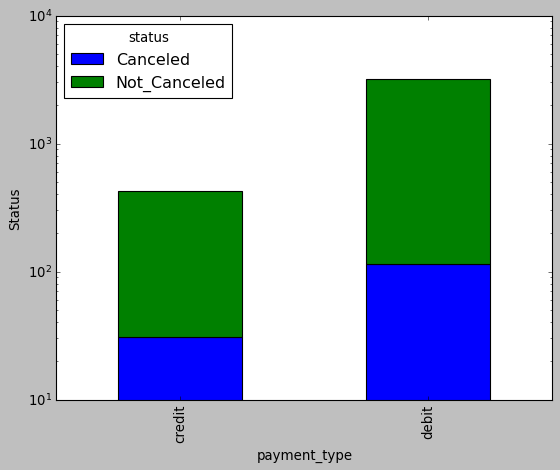

In [14]:
check_table1 = pd.crosstab(TD['payment_type'], TD['status'])
print(check_table1)

# Visualize 
fig1 = check_table1.plot(kind='bar', stacked=True, logy=True)
fig1.set_ylabel("Status")
plt.show()

In [15]:
# Check for influence of payment type on the "status"
chi2, p, dof, expected = chi2_contingency(check_table1)
print(f"P-value: {p}")

P-value: 0.00039564115798848857


#### As P-value, is < 0.05, payment type can influence the cancellation, hence is not discarded

In [16]:
# Describe based on data types
TD.describe(include=['object']).T

,count,unique,top,freq
id,3608,3608,TID32798,1
app_or_website,3608,2,website,2127
customer_segmentation,3608,6,group_1,2752
payment_type,3608,2,debit,3184
slot_date,3608,387,2018-07-22 00:00:00,48
store_number,3608,100,id_2,53
status,3608,2,Not_Canceled,3463


status                 Canceled  Not_Canceled
customer_segmentation                        
group_1                     115          2637
group_2                       3            96
group_4                      20           621
group_5                       0            20
group_6                       6            80
group_7                       1             9


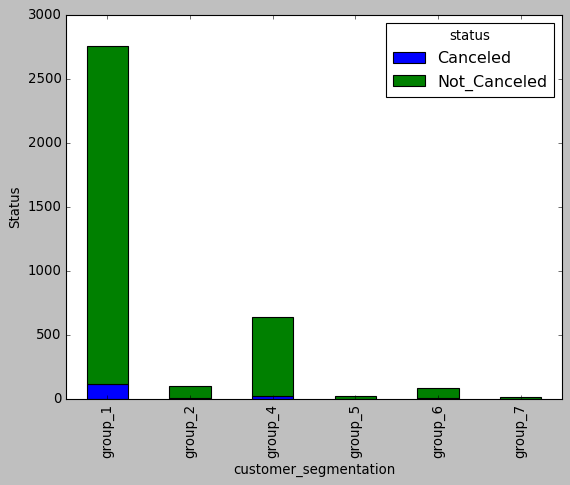

P-value: 0.3589332866317036


In [17]:
# Check for influence of customer_segmentation on the "status"
TD['customer_segmentation'].value_counts()

check_table2 = pd.crosstab(TD['customer_segmentation'], TD['status'])
print(check_table2)

# Visualize 
fig1 = check_table2.plot(kind='bar', stacked=True)
fig1.set_ylabel("Status")
plt.show()

chi2, p, dof, expected = chi2_contingency(check_table2)
print(f"P-value: {p}")

As P-value for customer_segmentation is greater than 0.35, it is statistically important. Howeer, the most data is concentrated for group_1 and hence, is dropped later.

In [18]:
TD['slot_date'].value_counts()     # checking for unique values 

2018-07-22 00:00:00    48
2018-08-26 00:00:00    47
2018-09-23 00:00:00    44
2019-05-16 00:00:00    36
2018-12-27 00:00:00    32
                       ..
2018-07-08 00:00:00     1
2018-07-15 00:00:00     1
2018-12-17 00:00:00     1
2018-09-04 00:00:00     1
2018-06-29 00:00:00     1
Name: slot_date, Length: 387, dtype: int64

In [19]:
TD['store_number'].value_counts()  # checking for unique values count

id_2     53
id_56    48
id_94    47
id_96    47
id_13    46
         ..
id_41    27
id_52    27
id_0     24
id_32    21
id_5     19
Name: store_number, Length: 100, dtype: int64

### Check for store number affecting cancellation rate 

status        Canceled  Not_Canceled
store_number                        
id_0                 0            24
id_1                 0            37
id_10                1            38
id_11                1            43
id_12                0            31
...                ...           ...
id_95                2            29
id_96                7            40
id_97                0            33
id_98                1            30
id_99                2            35

[100 rows x 2 columns]


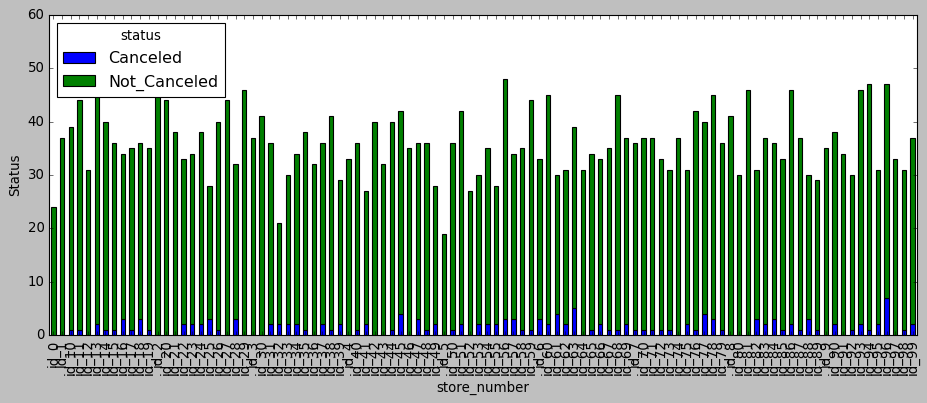

P-value: 0.15781784971725313


In [20]:
check_table3 = pd.crosstab(TD['store_number'], TD['status'])
print(check_table3)

# Visualize 
fig1 = check_table3.plot(kind='bar', stacked=True, figsize=(14, 5))
fig1.set_ylabel("Status")
plt.show()

chi2, p, dof, expected = chi2_contingency(check_table3)
print(f"P-value: {p}")

#### P-value > 0.05  hence the cancellation is independent from store number and customer segmentation and also can be seen in the graph above

### Based on the above analysis, Training dataframe drops: 
#### store_number, slot_date, customer_segmentation, app_or_website, and customer id.

In [21]:
TD = TD.drop(['id', 'store_number', 'slot_date', 'customer_segmentation', 'app_or_website'], axis=1)

In [22]:
TD.describe(include=['object']).T

,count,unique,top,freq
payment_type,3608,2,debit,3184
status,3608,2,Not_Canceled,3463


 ### <font color='blue'>  As stated above, payment type can affect the cancellation decision and is in object format. Hence, as only 2 unique options exists (debit and credit), the object type is converted into binary number 1 (for credit) and 2 (for debit) before fitting the model. </font>
 

In [23]:
# Convert to 1 and 2, then cast to float
TD['payment_type'] = TD['payment_type'].map({'credit': 1, 'debit': 2}).astype(float)

In [24]:
print(TD["payment_type"].value_counts())

2.0    3184
1.0     424
Name: payment_type, dtype: int64


In [25]:
TD.describe(include=['object']).T

,count,unique,top,freq
status,3608,2,Not_Canceled,3463


#### The "status" data type in the further section is converted to boolean for fitting the model

### Checking for Outlier and Distribution

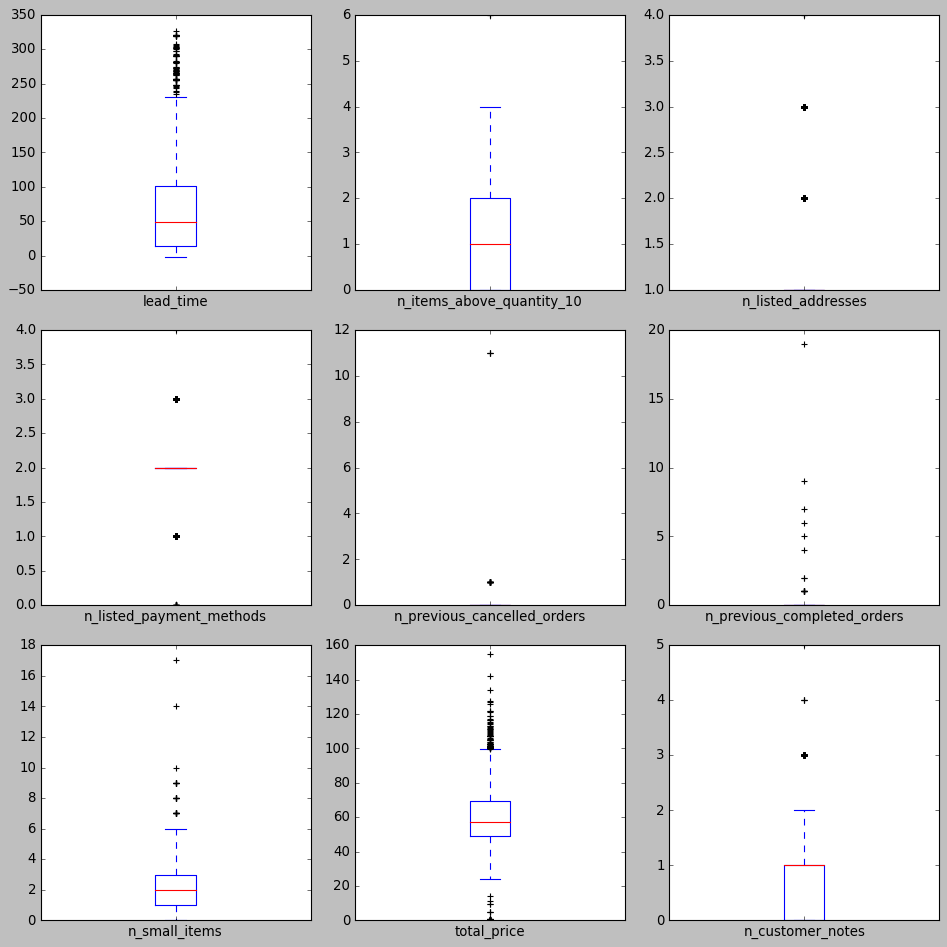

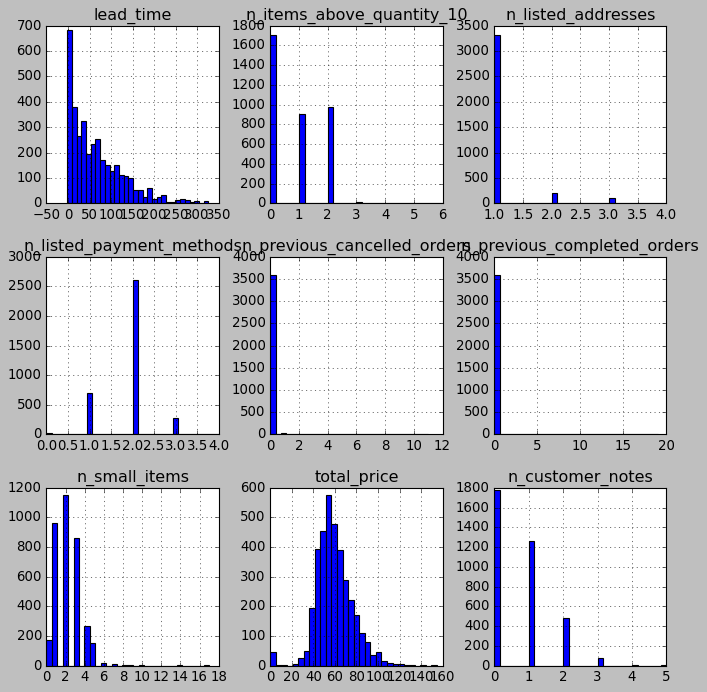

In [26]:
# Filter for numeric columns before plotting

cols_to_plot = ['lead_time', 'n_items_above_quantity_10', 'n_listed_addresses', 
    'n_listed_payment_methods', 'n_previous_cancelled_orders', 
    'n_previous_completed_orders', 'n_small_items', 'total_price' ,'n_customer_notes' ]             # List of specific columns to plot

# Plotting with a 3x3 layout to fit all 8 columns
TD[cols_to_plot].plot(kind='box', subplots=True, layout=(3,3), figsize=(12,12))
plt.tight_layout()
plt.show()

#  Histogram (Distribution)
TD[cols_to_plot].hist(bins=30, figsize=(10,10))
plt.show()

In [27]:
TD.describe(include=['float']).T    # check if everything is behaving correctly

,count,mean,std,min,25%,50%,75%,max
customer_collects,3608.0,0.036031,0.186393,0.000000,0.000000,0.000000,0.000000,1.000000
is_a_repeat_order,3608.0,0.010809,0.103419,0.000000,0.000000,0.000000,0.000000,1.000000
lead_time,3608.0,66.443935,63.047855,-1.635452,14.439108,49.320804,100.913498,326.084295
n_customer_notes,3608.0,0.690410,0.794559,0.000000,0.000000,1.000000,1.000000,5.000000
n_items_above_quantity_10,3608.0,0.814024,0.869374,0.000000,0.000000,1.000000,2.000000,6.000000
n_listed_addresses,3608.0,1.110310,0.394759,1.000000,1.000000,1.000000,1.000000,4.000000
n_listed_payment_methods,3608.0,1.870011,0.523375,0.000000,2.000000,2.000000,2.000000,4.000000
n_previous_cancelled_orders,3608.0,0.015244,0.326350,0.000000,0.000000,0.000000,0.000000,11.000000
n_previous_completed_orders,3608.0,0.017461,0.402343,0.000000,0.000000,0.000000,0.000000,19.000000
n_small_items,3608.0,2.217849,1.320623,0.000000,1.000000,2.000000,3.000000,17.000000


In [28]:
# Checking for unique value counts for the relevant columns
for col in cols_to_plot:
    print(f"\n--- {col} ---")
    print(TD[col].value_counts())


--- lead_time ---
12.421322     1
2.417240      1
109.422514    1
60.628822     1
0.621348      1
             ..
168.652236    1
56.458222     1
116.642853    1
7.601768      1
6.237735      1
Name: lead_time, Length: 3608, dtype: int64

--- n_items_above_quantity_10 ---
0.0    1705
2.0     973
1.0     906
3.0      15
4.0       7
6.0       2
Name: n_items_above_quantity_10, dtype: int64

--- n_listed_addresses ---
1.0    3312
2.0     196
3.0      98
4.0       2
Name: n_listed_addresses, dtype: int64

--- n_listed_payment_methods ---
2.0    2613
1.0     707
3.0     270
0.0      17
4.0       1
Name: n_listed_payment_methods, dtype: int64

--- n_previous_cancelled_orders ---
0.0     3583
1.0       22
11.0       3
Name: n_previous_cancelled_orders, dtype: int64

--- n_previous_completed_orders ---
0.0     3591
1.0        9
2.0        2
9.0        1
19.0       1
5.0        1
4.0        1
6.0        1
7.0        1
Name: n_previous_completed_orders, dtype: int64

--- n_small_items ---
2.0  

In [29]:
print(TD["n_listed_payment_methods"].value_counts())

# Dropping n_payment_method as mean =2; also n_listed_addresses
# TD = TD.drop(['n_listed_payment_methods', 'n_listed_addresses'], axis=1)

2.0    2613
1.0     707
3.0     270
0.0      17
4.0       1
Name: n_listed_payment_methods, dtype: int64


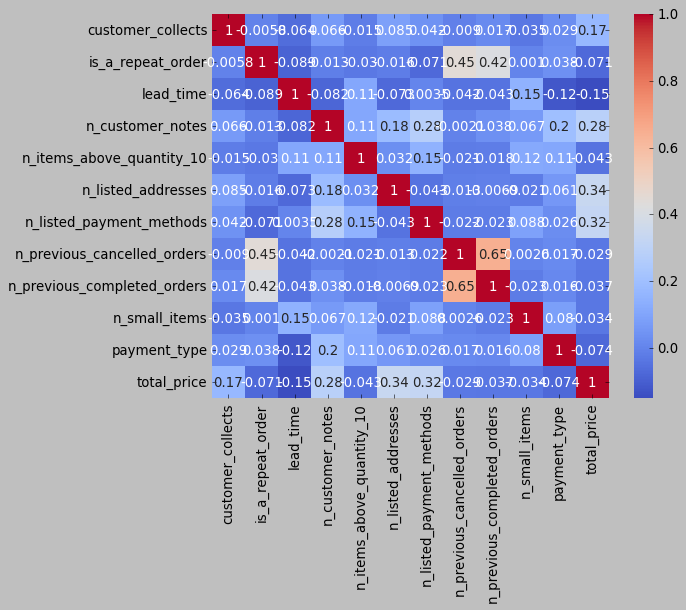

In [30]:
# Correlation Heatmap
correlation_matrix = TD.select_dtypes(include=['number']).corr()   # Select only numeric columns first, then correlate

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

### Key inference from the correlation matrix

#### <font color='blue'> All the variable, neglecting Order status, have low correlation with each other; except for "n_previous_cancelled_orders"  and "n_previous_completed_orders". </font>


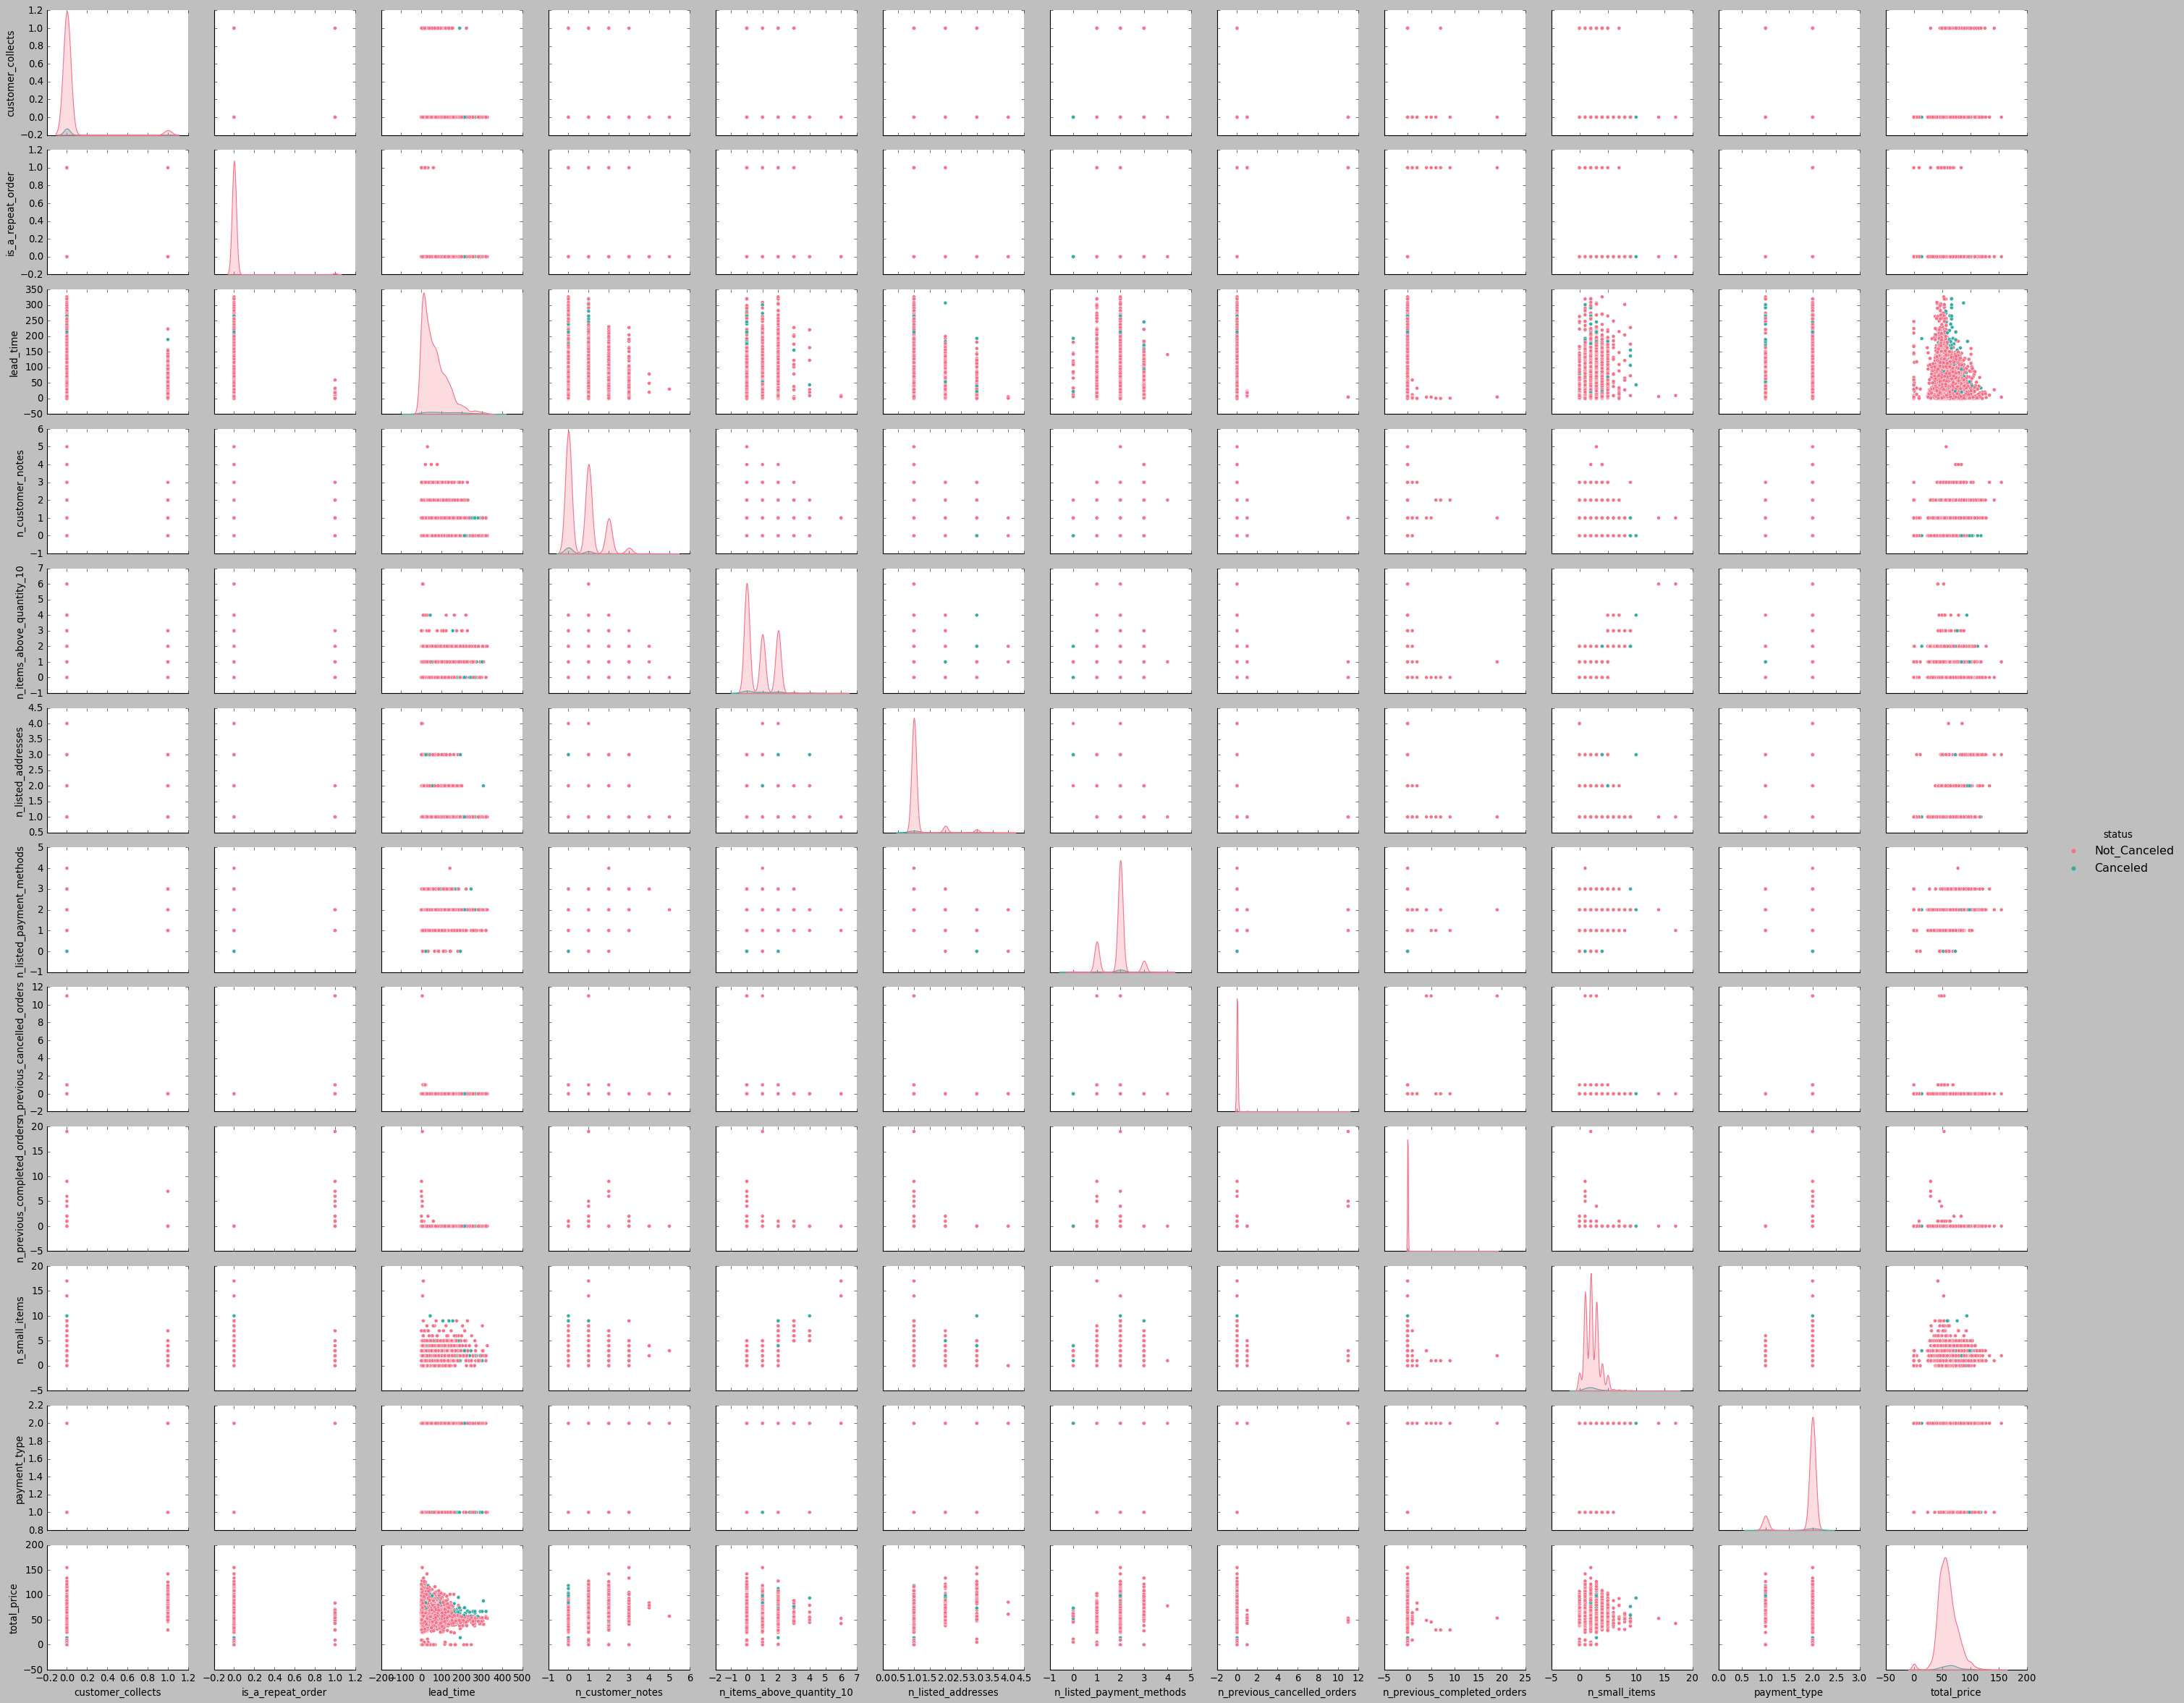

In [31]:
# Pairplot (Relationship Trends)
sns.pairplot(TD, hue='status',palette='husl',height=2.5, aspect=1.2) 
plt.show()

### The two key takeways are: 
#### <font color='blue'> - lead_time, total price, and n_small_items show variance, and distinch patterns with respect to order status </font> 
#### <font color='blue'>  - All the other variables, as seen from the heatmap, shows low inter-correlation. </font> 

#### <font color='blue'> Hence, all the column dataset, post the data cleaning, will be employed to fit predictive model.  </font> 

## ------------------------------------------------------------------------------------------------------------------
## Step 5: Fitting machine learning model


# <font color='magenta'>Part II – Building the model</font> 

## Algorithm trial 1: Logistic Regression

As the target variable is "canceled" and "not_canceled", Logistic regrsesion will be used as it good to fit binary output

Hence, the "canceled" and "not_canceled" will be converted to boolean "True" and "False" for "status" column

In [32]:
TD_a = TD.copy()  # Copy the original dataframe just for logistic regression

# Convert status to boolean
TD_a["status_bool"] = TD_a["status"].map({
    "Canceled": True,
    "Not_Canceled": False
})


TD_a = TD_a.drop(columns=["status"])   # Dropping the original status column  before fitting


In [33]:
# 1. Split Features and Target
X = TD_a.drop(columns=['status_bool'])
y = TD_a['status_bool']

# 2. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# 4. Calculate Probabilities and AUC
y_probs = lr.predict_proba(X_test)[:, 1]
auc_val = roc_auc_score(y_test, y_probs)

print(f"ROC-AUC Score: {auc_val:.4f}")

ROC-AUC Score: 0.7488


###  Plotting the  AUC curve

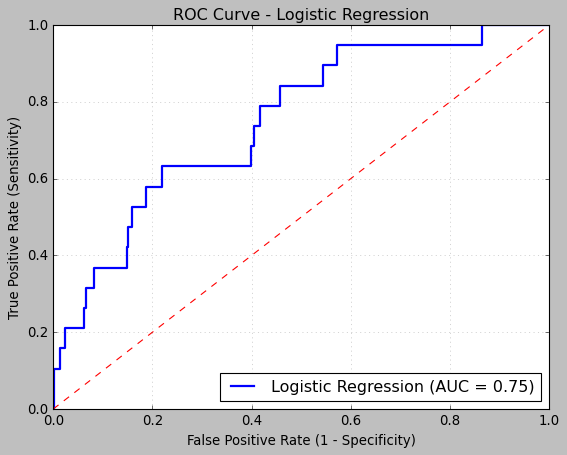

In [34]:
# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_val:.2f})', linewidth=2)
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Diagonal random baseline

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

#### Chi-square test

In [35]:
# Test for Payment Type
contingency = pd.crosstab(TD['payment_type'], TD['status'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-Square P-value: {p:.5f}")

Chi-Square P-value: 0.00040



### Goodness of Fit (AUC = 0.75)

An AUC of 0.75 shows a good model fit. While it discriminates cancellations significantly better, the high False Positive Rate near to 0.9, required to hit high sensitivity suggests the model is "liberal"—capturing most  cancellations but also can trigger many false cancellations.

### Chi-Square Test Conclusion

The Chi-Square test confirms that categorical variables are statistically significant p < 0.05. This proves a dependent relationship exists; variables like "payment_type" are not random and provide effectively predict signal, justifying their inclusion alongside numeric features in the final model.

---------------------------------------------------
## Algorithm trial 2: Ramdom Forest

Similar to logistic regression, the target variable is kept staus as boolean "canceled" and "not_canceled".

In [36]:
# Fit Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions and Probabilities
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate and Print Key Performance Indicators
auc_val = roc_auc_score(y_test, y_probs)
acc_val = accuracy_score(y_test, y_pred)

print("--- Random Forest Performance KPIs ---")
print(f"ROC-AUC Score: {auc_val:.4f}")
print(f"Accuracy Score: {acc_val:.4f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

--- Random Forest Performance KPIs ---
ROC-AUC Score: 0.7642
Accuracy Score: 0.9751

Detailed Classification Report:
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       703
        True       0.57      0.21      0.31        19

    accuracy                           0.98       722
   macro avg       0.78      0.60      0.65       722
weighted avg       0.97      0.98      0.97       722



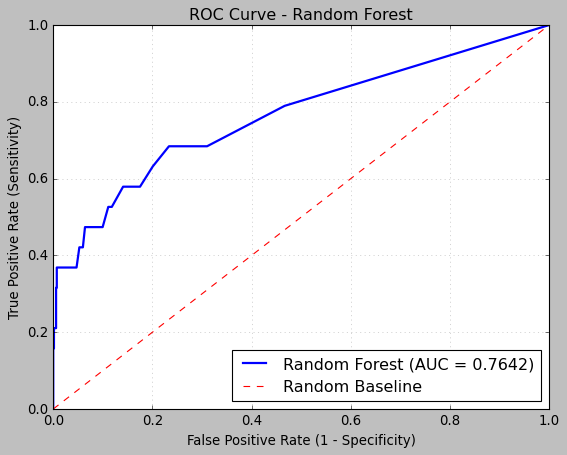

In [37]:
# Calculate ROC Curve values for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_probs)

# Plotting the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', label=f'Random Forest (AUC = {auc_val:.4f})',linewidth=2)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Baseline')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

##  Key takeways:
- The Accuracy of 97.5% accuracy is as not >90% of the test data is "Not Canceled" (703 vs 19). That is the model looks artificially successful simply by defaulting to the majority class almost every time.

- The model's ability to predict the actual target is poor as the recall of 0.21 for the "True" class, i.e., the model completely missed 79% of the users who actually canceled.

- An AUC of 0.76 indicates the features do have decent predictive power, but the default threshold fails here.

## Outcome & Decision:

### Considering Random Forest has a poor recall ratio, Logistic Regression fitted model shall be used for prediciton purposes.

## -----------------------------------------------------------------------------------------------------------------------------

# <font color='magenta'>Part III – Making Predictions</font> 

## Load Prediction Data

In [38]:
PD = pd.read_csv('../tesco-dataset/df_predict.csv')

# Match the PD with Training Data to match identically
PD['customer_collects'] = PD['customer_collects'].fillna(0.0)

# Drop column same as training data
PD = PD.drop(['store_number', 'slot_date', 'customer_segmentation', 'app_or_website'], axis=1)

# Convert to 1 and 2, then cast to float
PD['payment_type'] = PD['payment_type'].map({'credit': 1, 'debit': 2}).astype(float)

for col in PD.columns:
    if PD[col].nunique() > 20:
        print(f"Unique values in {col}: More than 20 unique values")
    else:
        print(f"Unique values in {col}: {PD[col].unique()}")

PD.info()      

Unique values in id: More than 20 unique values
Unique values in customer_collects: [0. 1.]
Unique values in is_a_repeat_order: [ 0. nan  1.]
Unique values in lead_time: More than 20 unique values
Unique values in n_customer_notes: [0. 1. 2. 3. 4.]
Unique values in n_items_above_quantity_10: [0. 1. 2. 4. 3.]
Unique values in n_listed_addresses: [1. 2. 3.]
Unique values in n_listed_payment_methods: [ 2.  3.  1. nan  0.  4.]
Unique values in n_previous_cancelled_orders: [0. 5. 3. 4. 1.]
Unique values in n_previous_completed_orders: [ 0.  1.  4. 51. 11.  2. 21.  3. 12. 19. 31. 43.  7.  5.  6. 20. 45. 18.]
Unique values in n_small_items: [ 2.  1.  4.  3.  0.  7.  5. 10.  8.  6.]
Unique values in payment_type: [2. 1.]
Unique values in total_price: More than 20 unique values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  ----- 

In [39]:
PD.isnull().sum()

# Check if is_a_repeat_order  and  n_listed_payment_methods fall for same row
maskPD_payment_nan = PD['n_listed_payment_methods'].isna()
maskPD_repeat_nan = PD['is_a_repeat_order'].isna()

# Delete the NAN rows as there less than 10%
if maskPD_payment_nan.equals(maskPD_repeat_nan):
    print("Both columns have NaN values in the same rows.")
    PD = PD.dropna(  subset=['n_listed_payment_methods', 'is_a_repeat_order'],      how='all')


# To get the IDs for prediction
PD_ids = PD['id']
PD = PD.drop(['id'], axis=1)

PD.info()

Both columns have NaN values in the same rows.
<class 'pandas.core.frame.DataFrame'>
Int64Index: 916 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_collects            916 non-null    float64
 1   is_a_repeat_order            916 non-null    float64
 2   lead_time                    916 non-null    float64
 3   n_customer_notes             916 non-null    float64
 4   n_items_above_quantity_10    916 non-null    float64
 5   n_listed_addresses           916 non-null    float64
 6   n_listed_payment_methods     916 non-null    float64
 7   n_previous_cancelled_orders  916 non-null    float64
 8   n_previous_completed_orders  916 non-null    float64
 9   n_small_items                916 non-null    float64
 10  payment_type                 916 non-null    float64
 11  total_price                  916 non-null    float64
dtypes: float64(12)
memory usage: 93

###  The Prediction Dataframe data matches with the training dataframe

In [40]:
# 1 [:, 1] extracts the probability for the "True" (Canceled) 
PD_probs = lr.predict_proba(PD)[:, 1]

# 2. If probability> 0.5 , then its canceled
PD_predicted_status = np.where(PD_probs > 0.5, 'Canceled', 'Not_Canceled')

# 3. Final results in DataFrame
prediction_results = pd.DataFrame({
    'Id': PD_ids,
    'cancellation_risk_score': PD_probs,
    'predicted_status': PD_predicted_status
})

# 4. Sort from highest risk score to lowest
prediction_results_sorted = prediction_results.sort_values(by='cancellation_risk_score', ascending=False)

# 5. Display the final output
print("--- Predicted Order Cancellations (Highest Risk First) ---")
print(prediction_results_sorted.head(20).to_string(index=False))


--- Predicted Order Cancellations (Highest Risk First) ---
      Id  cancellation_risk_score predicted_status
TID18508                 0.894369         Canceled
TID07091                 0.855002         Canceled
TID17515                 0.854063         Canceled
TID13687                 0.679772         Canceled
TID00177                 0.666871         Canceled
TID25614                 0.599531         Canceled
TID09707                 0.589084         Canceled
TID35784                 0.571056         Canceled
TID02574                 0.559849         Canceled
TID15495                 0.559239         Canceled
TID03199                 0.540362         Canceled
TID31108                 0.511625         Canceled
TID30641                 0.508864         Canceled
TID16177                 0.507258         Canceled
TID11892                 0.507192         Canceled
TID34986                 0.487386     Not_Canceled
TID17567                 0.486799     Not_Canceled
TID29846               

### To stude the influencing factor for order cancelling, SHAP values are evaluated below.

C:\Users\cege\miniconda3\lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


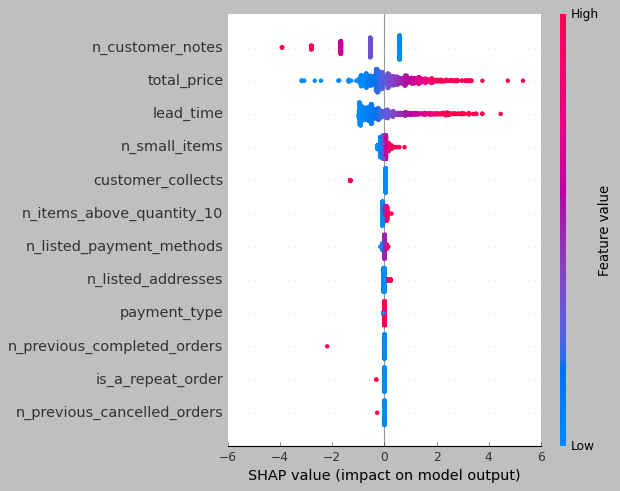

In [41]:
# 1. Create SHAP explainer  (SHapley Additive exPlanations) 
# We use X_train (not X_test) as the background dataset since the final model was trained on it
explainer = shap.LinearExplainer(
    lr,                     
    X_train,         
    feature_perturbation="interventional"
)

# 2. Calculate SHAP values for the prediction dataset features
shap_values = explainer.shap_values(PD)

# 3. Summary Plots to show global feature importance
shap.summary_plot(
    shap_values,
    PD,
    plot_type="dot",
    show=True
)


# <font color='magenta'>Part IV – Questions </font> 

Few response to questions asked are summarized below

# Conclusion

 <font color='green'> -It can be seen that, from the SHAP analysis figure, most significant influencing parameter is the total price and lead time. High order value, longer lead time, and lower customer notes strongly increase cancellation likelihood. Thus, cancellations are mainly driven by how a customer perceives the order and important factors related to delay in delivery and higher total prices. </font>
 
<font color='green'> -Interestingly, higher customer engagement, in the form of "n_customer_notes" reduces the cancellation risk. </font>

<font color='green'> -Also, the higher previous completed orders reduces the cancellations risk and is expected, along with customers who collect themselves. </font>

## Key takeaways to technical stakeholders:
-It can be recommended that to maximize the value of this cancellation prediction model the operations team shall implement a targeted intervention strategy to avoid order being cancelled. For instance customer digital teams should trigger automated SMS confirmations for these high-risk orders 48 hours prior to delivery. Additionally, for orders flagged with a >70% cancellation probability, warehouse staff should delay the physical picking of "small items" until closer to the delivery time, minimizing expensive cost on restocking.
 
-To improve our current baseline results, we must explicitly address the dataset's class imbalance, and aim for diverse data in for all classes. Furthermore, features like grouping "lead time" into distinct behavioral categories will ensure our model's performance remains highly robust and reliable in a production environment.

-Finally, to reduce the cancellation, the customer engagment shall be increased, by sending an SMS or app notification asking for any changes in delivery time. 

-The data shall add classificaiton based on item type, item price, customer age group, etc for understanding and improving the model.


## Key takeaways to non-technical stakeholders:

-It can be recommended to flag off, using Tableau dashboard, high risk cancellation orders. This can include providing a dashbord with Red-Amber-Green risk matrix for tangible labor cost-savings of our model.
 
-Particularly focusing on the customer experience enhancement, especilly for customers with several previously cancelled order. The changes in execution over time will provide data that help understand whether the business is improving in terms of customer satisfaction. Thus, it is also recommended that to automise and develop a dashboard to check the trend of cancellation orders, and also evaluating the significant influencing parameters. 
